# Notebook 1 — Python, NumPy, Pandas, APIs and Saving Data

**Who this is for:** someone who has never written Python before.

**How to use this notebook:** click on a cell and press `Shift + Enter` to run it.
Read the text cell first, then run the code cell below it. Change the numbers and
run it again — breaking things is how you learn.

**What we cover**

1. Python basics (variables, lists, dictionaries, loops, functions)
2. NumPy (fast maths on numbers)
3. Pandas (tables of data)
4. APIs (getting data from the internet)
5. Saving data to Excel and Google Sheets
6. One fully solved question using everything
7. One practice question for you

## 0. Setup

Run this cell once. If you get a `ModuleNotFoundError`, remove the `#` in front of
the `!pip install` line, run the cell, then put the `#` back.

In [212]:
pip install numpy pandas matplotlib requests openpyxl yfinance


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [214]:
#pip install numpy pandas matplotlib requests openpyxl yfinance

import sys
print("Python version:", sys.version.split()[0])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("Setup complete.")

Python version: 3.11.7
numpy: 1.26.4
pandas: 2.1.4
Setup complete.



---
# 1. Python Basics

## 1.1 Variables and data types

A **variable** is a name that stores a value. You do not have to declare the type —
Python figures it out.

The four types you will use constantly:

| Type | Meaning | Example |
|---|---|---|
| `int` | whole number | `25` |
| `float` | decimal number | `24500.75` |
| `str` | text (in quotes) | `"NIFTY"` |
| `bool` | True or False | `True` |

`#` starts a comment — Python ignores everything after it.

In [78]:
symbol = "NIFTY"        # str
spot_price = 24500.75   # float
lot_size = 75           # int
is_open = True          # bool

print(symbol, spot_price, lot_size, is_open)

# type() tells you what kind of value something is
print(type(symbol), type(spot_price), type(lot_size), type(is_open))

NIFTY 24500.75 75 True
<class 'str'> <class 'float'> <class 'int'> <class 'bool'>


## 1.2 Maths and f-strings

Python does arithmetic with `+ - * /`. Two extras worth knowing:
`**` is power, and `//` is division that throws away the decimal part.

An **f-string** lets you drop variables straight into text. Put `f` before the
quotes and wrap the variable in `{}`. `{value:.2f}` means "show 2 decimal places".

In [80]:
contract_value = spot_price * lot_size

print(contract_value)                                    # plain
print("Contract value is", contract_value)               # comma-separated
print(f"One {symbol} lot is worth Rs {contract_value:,.2f}")   # f-string, 2 decimals, commas

print("Power:", 2 ** 10)
print("Whole division:", 17 // 5, "and the remainder:", 17 % 5)

1837556.25
Contract value is 1837556.25
One NIFTY lot is worth Rs 1,837,556.25
Power: 1024
Whole division: 3 and the remainder: 2


## 1.3 Lists

A **list** is an ordered collection. Written with square brackets `[]`.

Counting starts at **0**, not 1. So the first item is `prices[0]`.
A negative index counts from the end: `prices[-1]` is the last item.

In [82]:
prices = [24500, 24610, 24480, 24720, 24655]

print("Whole list :", prices)
print("First      :", prices[0])
print("Last       :", prices[-1])
print("Items 1 to 3:", prices[1:4])   # start is included, stop is NOT
print("How many   :", len(prices))

prices.append(24800)      # add to the end
print("After append:", prices)

print("Highest:", max(prices), " Lowest:", min(prices), " Total:", sum(prices))

Whole list : [24500, 24610, 24480, 24720, 24655]
First      : 24500
Last       : 24655
Items 1 to 3: [24610, 24480, 24720]
How many   : 5
After append: [24500, 24610, 24480, 24720, 24655, 24800]
Highest: 24800  Lowest: 24480  Total: 147765


## 1.4 Dictionaries

A **dictionary** stores data as `key: value` pairs, written with curly braces `{}`.
Instead of looking things up by position, you look them up by name.

This matters a lot later: data that comes back from an API is almost always
shaped like a dictionary.

In [84]:
trade = {
    "symbol": "NIFTY",
    "strike": 24500,
    "type": "CE",
    "price": 152.35,
    "quantity": 75,
}

print(trade)
print("Strike is:", trade["strike"])       # look up by key

trade["price"] = 160.00                    # change a value
trade["expiry"] = "2025-01-30"             # add a new key

print("All the keys:", list(trade.keys()))
print("Updated trade:", trade)

{'symbol': 'NIFTY', 'strike': 24500, 'type': 'CE', 'price': 152.35, 'quantity': 75}
Strike is: 24500
All the keys: ['symbol', 'strike', 'type', 'price', 'quantity', 'expiry']
Updated trade: {'symbol': 'NIFTY', 'strike': 24500, 'type': 'CE', 'price': 160.0, 'quantity': 75, 'expiry': '2025-01-30'}


## 1.5 if / elif / else

Used to make decisions. Notice the **colon** at the end of the line and the
**indentation** (4 spaces) on the next line — Python uses indentation instead of
brackets to know what belongs inside the `if`.

Comparisons: `==` equal, `!=` not equal, `>` `<` `>=` `<=`.
(A single `=` assigns a value; a double `==` compares. This trips up everyone once.)

In [86]:
strike = 24500
spot = 24720

if spot > strike:
    print("Call option is In The Money")
elif spot == strike:
    print("Call option is At The Money")
else:
    print("Call option is Out of The Money")

# Combine conditions with 'and' / 'or'
volume = 1_20_000
if spot > strike and volume > 100000:
    print("ITM and liquid")

Call option is In The Money
ITM and liquid


## 1.6 Loops

A **for loop** repeats an action once for every item in a list.

`range(5)` produces the numbers 0, 1, 2, 3, 4 — handy when you want to repeat
something a fixed number of times.

In [88]:
prices = [24500, 24610, 24480, 24720, 24655]

for p in prices:
    print("Price:", p)

print("---")

# enumerate() gives you the position AND the value
for i, p in enumerate(prices):
    print(f"Day {i + 1}: {p}")

print("---")

# Building a new list inside a loop
returns = []
for i in range(1, len(prices)):
    r = (prices[i] - prices[i - 1]) / prices[i - 1] * 100
    returns.append(round(r, 3))

print("Daily returns in %:", returns)

Price: 24500
Price: 24610
Price: 24480
Price: 24720
Price: 24655
---
Day 1: 24500
Day 2: 24610
Day 3: 24480
Day 4: 24720
Day 5: 24655
---
Daily returns in %: [0.449, -0.528, 0.98, -0.263]


## 1.7 Functions

A **function** is a reusable block of code that you give a name.
`def` defines it, and `return` sends a value back to whoever called it.

Write a function whenever you notice yourself copy-pasting the same lines.

In [90]:
def pct_change(old, new):
    # Returns the percentage change from old to new.
    change = (new - old) / old * 100
    return round(change, 2)


print(pct_change(24500, 24720))
print(pct_change(100, 90))


# A default value: if you do not pass lot_size, it uses 75
def contract_value(price, lot_size=75):
    return price * lot_size


print(contract_value(24500))
print(contract_value(24500, lot_size=50))

0.9
-10.0
1837500
1225000


---
# 2. NumPy

NumPy gives you the **array**: a list-like container built for numbers.

Why not just use a list? Two reasons:

1. **Maths works on the whole thing at once.** `array * 2` doubles every element.
   With a list you would need a loop.
2. **It is far faster** on large amounts of data, because the heavy lifting happens
   in C rather than Python.

By convention it is imported as `np`.

In [92]:
import numpy as np

prices = np.array([24500, 24610, 24480, 24720, 24655])

print(prices)
print("Type      :", type(prices))
print("Shape     :", prices.shape)   # (5,) means 5 items in 1 dimension
print("Data type :", prices.dtype)

# Some ready-made arrays
print(np.zeros(5))            # five zeros
print(np.ones(3))             # three ones
print(np.arange(0, 10, 2))    # start, stop (excluded), step
print(np.linspace(0, 1, 5))   # 5 evenly spaced numbers between 0 and 1

[24500 24610 24480 24720 24655]
Type      : <class 'numpy.ndarray'>
Shape     : (5,)
Data type : int64
[0. 0. 0. 0. 0.]
[1. 1. 1.]
[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]


## 2.1 Maths on a whole array (vectorisation)

This is the headline feature. Do the operation once, it applies to every element.
No loop needed.

In [94]:
prices = np.array([24500, 24610, 24480, 24720, 24655])

print("Add 100 to each   :", prices + 100)
print("Convert to lots   :", prices * 75)
print("Half of each      :", prices / 2)

# Two arrays of the same length work element by element
qty = np.array([1, 2, 1, 3, 2])
print("Price x quantity  :", prices * qty)

# Useful built-in maths
print("Square root of 144:", np.sqrt(144))
print("Natural log       :", np.round(np.log(prices), 4))

Add 100 to each   : [24600 24710 24580 24820 24755]
Convert to lots   : [1837500 1845750 1836000 1854000 1849125]
Half of each      : [12250.  12305.  12240.  12360.  12327.5]
Price x quantity  : [24500 49220 24480 74160 49310]
Square root of 144: 12.0
Natural log       : [10.1064 10.1109 10.1056 10.1154 10.1127]


## 2.2 Picking out parts of an array

Same square-bracket rules as lists: `array[0]` is the first item,
`array[1:4]` is a slice, `array[-1]` is the last.

In [96]:
prices = np.array([24500, 24610, 24480, 24720, 24655])

print("First      :", prices[0])
print("Last       :", prices[-1])
print("Middle bit :", prices[1:4])
print("Every other:", prices[::2])

# A 2D array: rows and columns. First index is the row, second is the column.
grid = np.array([[24500, 152.3],
                 [24600, 118.7],
                 [24700,  91.2]])

print("\nShape:", grid.shape, "-> 3 rows, 2 columns")
print("Row 0        :", grid[0])
print("Row 0, col 1 :", grid[0, 1])
print("All strikes  :", grid[:, 0])   # ':' means 'every row'

First      : 24500
Last       : 24655
Middle bit : [24610 24480 24720]
Every other: [24500 24480 24655]

Shape: (3, 2) -> 3 rows, 2 columns
Row 0        : [24500.    152.3]
Row 0, col 1 : 152.3
All strikes  : [24500. 24600. 24700.]


## 2.3 Summarising an array

These are the functions you will reach for every single time you look at data.
We go much deeper into what they *mean* in Notebook 2.

In [98]:
prices = np.array([24500, 24610, 24480, 24720, 24655])

print("Sum      :", prices.sum())
print("Mean     :", prices.mean())
print("Median   :", np.median(prices))
print("Std dev  :", round(prices.std(), 2))
print("Min / Max:", prices.min(), "/", prices.max())

# argmin / argmax give the POSITION of the smallest / largest value
print("Position of the highest price:", prices.argmax())

Sum      : 122965
Mean     : 24593.0
Median   : 24610.0
Std dev  : 91.3
Min / Max: 24480 / 24720
Position of the highest price: 3


## 2.4 Filtering with conditions

Compare an array to a number and you get back an array of `True`/`False`
(a **boolean mask**). Feed that mask back into the array and you keep only the
rows where it was `True`.

This is the single most useful NumPy trick.

In [100]:
prices = np.array([24500, 24610, 24480, 24720, 24655])

mask = prices > 24600
print("The mask       :", mask)
print("Values kept    :", prices[mask])
print("In one line    :", prices[prices > 24600])
print("How many       :", (prices > 24600).sum())   # True counts as 1

# Two conditions: use & for 'and', | for 'or'. Each condition needs its own brackets.
print("Between 24500 and 24700:", prices[(prices > 24500) & (prices < 24700)])

# np.where(condition, value_if_true, value_if_false)
labels = np.where(prices > 24600, "high", "low")
print(labels)

The mask       : [False  True False  True  True]
Values kept    : [24610 24720 24655]
In one line    : [24610 24720 24655]
How many       : 3
Between 24500 and 24700: [24610 24655]
['low' 'high' 'low' 'high' 'high']


## 2.5 Random numbers

Used for simulations and for making up test data. Setting a **seed** fixes the
randomness so you get the same numbers every time you run it — which matters when
you want your results to be reproducible.

In [102]:
rng = np.random.default_rng(seed=42)   # 42 is arbitrary, any number works

print("5 random decimals 0-1 :", np.round(rng.random(5), 3))
print("5 random whole numbers:", rng.integers(1, 100, size=5))

# Numbers from a normal (bell curve) distribution: mean 0, std dev 1
sample = rng.normal(loc=0, scale=1, size=1000)
print("Sample mean:", round(sample.mean(), 4), " Sample std:", round(sample.std(), 4))

5 random decimals 0-1 : [0.774 0.439 0.859 0.697 0.094]
5 random whole numbers: [53 97 73 76 72]
Sample mean: -0.0263  Sample std: 0.9855


---
# 3. Pandas

NumPy handles rows of numbers. **Pandas** handles *tables* — columns with names,
mixed data types, dates, missing values. Think of it as Excel that you drive with code.

Two objects:

- **Series** — one column.
- **DataFrame** — the whole table (a bunch of Series side by side).

Imported as `pd` by convention.

In [104]:
import pandas as pd

# A Series is a single column with labels
s = pd.Series([152.3, 118.7, 91.2], index=["24500CE", "24600CE", "24700CE"])
print(s)
print("\nPrice of 24600CE:", s["24600CE"])

24500CE    152.3
24600CE    118.7
24700CE     91.2
dtype: float64

Price of 24600CE: 118.7


## 3.1 Making a DataFrame

The usual way: a dictionary where each key becomes a column name and each value
is a list of that column's data. All lists must be the same length.

In [106]:
data = {
    "strike":  [24300, 24400, 24500, 24600, 24700, 24800],
    "type":    ["CE",  "CE",  "CE",  "PE",  "PE",  "PE"],
    "ltp":     [310.5, 228.0, 152.3, 96.4,  141.8, 205.6],
    "oi":      [120000, 185000, 310000, 275000, 190000, 145000],
    "volume":  [45000, 62000, 98000, 71000, 53000, 39000],
}

df = pd.DataFrame(data)
df

,strike,type,ltp,oi,volume
0,24300,CE,310.5,120000,45000
1,24400,CE,228.0,185000,62000
2,24500,CE,152.3,310000,98000
3,24600,PE,96.4,275000,71000
4,24700,PE,141.8,190000,53000
5,24800,PE,205.6,145000,39000


## 3.2 Looking at your data

The first thing you do with any new dataset. Every one of these is worth running
before you touch anything else.

- `.head(n)` — first n rows (default 5)
- `.tail(n)` — last n rows
- `.shape` — (rows, columns)
- `.columns` — the column names
- `.dtypes` — the type of each column
- `.info()` — summary including how many values are missing
- `.describe()` — count, mean, std, min, quartiles, max for numeric columns

In [108]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\n--- dtypes ---")
print(df.dtypes)
print("\n--- info ---")
df.info()

Shape: (6, 5)
Columns: ['strike', 'type', 'ltp', 'oi', 'volume']

--- dtypes ---
strike      int64
type       object
ltp       float64
oi          int64
volume      int64
dtype: object

--- info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   strike  6 non-null      int64  
 1   type    6 non-null      object 
 2   ltp     6 non-null      float64
 3   oi      6 non-null      int64  
 4   volume  6 non-null      int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 372.0+ bytes


In [109]:
df.describe()

,strike,ltp,oi,volume
count,6.000000,6.000000,6.000000,6.000000
mean,24550.000000,189.100000,204166.666667,61333.333333
std,187.082869,75.773663,73987.611576,21322.914122
min,24300.000000,96.400000,120000.000000,39000.000000
25%,24425.000000,144.425000,155000.000000,47000.000000
50%,24550.000000,178.950000,187500.000000,57500.000000
75%,24675.000000,222.400000,253750.000000,68750.000000
max,24800.000000,310.500000,310000.000000,98000.000000


## 3.3 Selecting columns and rows

- One column: `df["ltp"]` → a Series
- Several columns: `df[["strike", "ltp"]]` → a DataFrame (note the **double** brackets)
- Rows by label: `df.loc[0]`
- Rows by position: `df.iloc[0]`

`loc` and `iloc` look similar. `loc` uses the index *label*, `iloc` uses the row
*number*. They are identical here because our index happens to be 0, 1, 2...

In [111]:
print(df["ltp"])
print("\n--- two columns ---")
print(df[["strike", "ltp"]])
print("\n--- first row ---")
print(df.loc[0])
print("\n--- rows 0 to 2, only strike and ltp ---")
print(df.loc[0:2, ["strike", "ltp"]])
print("\n--- by position: last row ---")
print(df.iloc[-1])

0    310.5
1    228.0
2    152.3
3     96.4
4    141.8
5    205.6
Name: ltp, dtype: float64

--- two columns ---
   strike    ltp
0   24300  310.5
1   24400  228.0
2   24500  152.3
3   24600   96.4
4   24700  141.8
5   24800  205.6

--- first row ---
strike     24300
type          CE
ltp        310.5
oi        120000
volume     45000
Name: 0, dtype: object

--- rows 0 to 2, only strike and ltp ---
   strike    ltp
0   24300  310.5
1   24400  228.0
2   24500  152.3

--- by position: last row ---
strike     24800
type          PE
ltp        205.6
oi        145000
volume     39000
Name: 5, dtype: object


## 3.4 Filtering rows

Exactly the boolean mask idea from NumPy, applied to a table.
Put the condition inside `df[ ... ]`.

In [113]:
# Only call options
calls = df[df["type"] == "CE"]
print(calls)

# Two conditions: & is 'and', | is 'or', each side in its own brackets
liquid_calls = df[(df["type"] == "CE") & (df["oi"] > 150000)]
print("\n--- liquid calls ---")
print(liquid_calls)

# isin() checks membership in a list
print("\n--- selected strikes ---")
print(df[df["strike"].isin([24500, 24700])])

   strike type    ltp      oi  volume
0   24300   CE  310.5  120000   45000
1   24400   CE  228.0  185000   62000
2   24500   CE  152.3  310000   98000

--- liquid calls ---
   strike type    ltp      oi  volume
1   24400   CE  228.0  185000   62000
2   24500   CE  152.3  310000   98000

--- selected strikes ---
   strike type    ltp      oi  volume
2   24500   CE  152.3  310000   98000
4   24700   PE  141.8  190000   53000


## 3.5 Adding and changing columns

Assign to a column name that does not exist yet and Pandas creates it.
The calculation applies to every row at once — no loop.

In [115]:
df["contract_value"] = df["ltp"] * 75
df["oi_lakhs"] = (df["oi"] / 100000).round(2)

# np.where for a conditional column
df["liquidity"] = np.where(df["oi"] > 200000, "high", "normal")

# apply() runs a function on every value of a column
df["ltp_rounded"] = df["ltp"].apply(lambda x: round(x))

df

,strike,type,ltp,oi,volume,contract_value,oi_lakhs,liquidity,ltp_rounded
0,24300,CE,310.5,120000,45000,23287.5,1.20,normal,310
1,24400,CE,228.0,185000,62000,17100.0,1.85,normal,228
2,24500,CE,152.3,310000,98000,11422.5,3.10,high,152
3,24600,PE,96.4,275000,71000,7230.0,2.75,high,96
4,24700,PE,141.8,190000,53000,10635.0,1.90,normal,142
5,24800,PE,205.6,145000,39000,15420.0,1.45,normal,206


## 3.6 Sorting and counting

In [117]:
print("--- sorted by OI, biggest first ---")
print(df.sort_values("oi", ascending=False))

print("\n--- how many of each type ---")
print(df["type"].value_counts())

print("\n--- unique values ---")
print(df["type"].unique())

--- sorted by OI, biggest first ---
   strike type    ltp      oi  volume  contract_value  oi_lakhs liquidity  \
2   24500   CE  152.3  310000   98000         11422.5      3.10      high   
3   24600   PE   96.4  275000   71000          7230.0      2.75      high   
4   24700   PE  141.8  190000   53000         10635.0      1.90    normal   
1   24400   CE  228.0  185000   62000         17100.0      1.85    normal   
5   24800   PE  205.6  145000   39000         15420.0      1.45    normal   
0   24300   CE  310.5  120000   45000         23287.5      1.20    normal   

   ltp_rounded  
2          152  
3           96  
4          142  
1          228  
5          206  
0          310  

--- how many of each type ---
type
CE    3
PE    3
Name: count, dtype: int64

--- unique values ---
['CE' 'PE']


## 3.7 Missing values

Real data always has gaps. Pandas shows them as `NaN` ("not a number").

- `.isna().sum()` — count the gaps per column
- `.dropna()` — delete rows that have gaps
- `.fillna(value)` — replace gaps with something

Which one you choose depends on the situation. Deleting is safe when gaps are rare;
filling is better when they are common and you have a sensible substitute.

In [119]:
df2 = df.copy()
df2.loc[1, "ltp"] = np.nan
df2.loc[4, "volume"] = np.nan

print("Missing per column:")
print(df2.isna().sum())

print("\nAfter dropping rows with gaps:", df2.dropna().shape)
print("After filling with 0        :", df2.fillna(0).isna().sum().sum(), "gaps left")

# Fill a column with its own average
df2["ltp"] = df2["ltp"].fillna(df2["ltp"].mean())
print("\nltp column after filling with the mean:")
print(df2["ltp"])

Missing per column:
strike            0
type              0
ltp               1
oi                0
volume            1
contract_value    0
oi_lakhs          0
liquidity         0
ltp_rounded       0
dtype: int64

After dropping rows with gaps: (4, 9)
After filling with 0        : 0 gaps left

ltp column after filling with the mean:
0    310.50
1    181.32
2    152.30
3     96.40
4    141.80
5    205.60
Name: ltp, dtype: float64


## 3.8 groupby — the workhorse

`groupby` splits the table into groups, applies a calculation to each group, and
puts the answers back together. "Average LTP **for each** option type" is a groupby.

Read `df.groupby("type")["ltp"].mean()` as: group by type, take the ltp column,
give me the mean of each group.

In [121]:
print("--- mean LTP by type ---")
print(df.groupby("type")["ltp"].mean())

print("\n--- several stats at once ---")
print(df.groupby("type")["ltp"].agg(["count", "mean", "min", "max"]))

print("\n--- different stats for different columns ---")
print(df.groupby("type").agg({"ltp": "mean", "oi": "sum", "volume": "max"}))

--- mean LTP by type ---
type
CE    230.266667
PE    147.933333
Name: ltp, dtype: float64

--- several stats at once ---
      count        mean    min    max
type                                 
CE        3  230.266667  152.3  310.5
PE        3  147.933333   96.4  205.6

--- different stats for different columns ---
             ltp      oi  volume
type                            
CE    230.266667  615000   98000
PE    147.933333  610000   71000


## 3.9 Reading and writing CSV files

A CSV is a plain text file where values are separated by commas. It is the most
common way data gets passed around.

- `pd.read_csv("file.csv")` — read it in
- `df.to_csv("file.csv", index=False)` — write it out

`index=False` stops Pandas from writing the row numbers as an extra column, which
you almost never want.

In [123]:
df.to_csv("sample_options.csv", index=False)
print("Saved.")

df_back = pd.read_csv("sample_options.csv")
print(df_back.head(3))

Saved.
   strike type    ltp      oi  volume  contract_value  oi_lakhs liquidity  \
0   24300   CE  310.5  120000   45000         23287.5      1.20    normal   
1   24400   CE  228.0  185000   62000         17100.0      1.85    normal   
2   24500   CE  152.3  310000   98000         11422.5      3.10      high   

   ltp_rounded  
0          310  
1          228  
2          152  


---
# 4. APIs — getting data from the internet

An **API** is a web address that returns *data* instead of a web page. You send a
request, a server sends data back.

The data almost always comes back as **JSON**, which in Python becomes a dictionary
(and dictionaries inside dictionaries, and lists of dictionaries).

The `requests` library does the fetching. The pattern is always the same:

```
response = requests.get(url)   # ask
data = response.json()          # turn the answer into a Python dictionary
```

A **status code** of 200 means it worked. 404 means not found, 403 means blocked,
500 means the server broke.

In [125]:
import requests

# Frankfurter is a free exchange rate API. No sign-up, no key needed.
url = "https://api.frankfurter.app/latest?from=USD&to=INR"

response = requests.get(url, timeout=10)
print("Status code:", response.status_code)

data = response.json()
print("\nThe raw JSON as a Python dictionary:")
print(data)

Status code: 200

The raw JSON as a Python dictionary:
{'amount': 1.0, 'base': 'USD', 'date': '2026-07-31', 'rates': {'INR': 95.39}}


## 4.1 Digging into the JSON

Once it is a dictionary, you pull out what you need with keys. Nested data means
chaining the keys: `data["rates"]["INR"]`.

Tip: `data.keys()` shows you what is available at each level. Use it to explore
before you write the code that extracts things.

In [127]:
print("Top-level keys:", list(data.keys()))
print("Base currency :", data["base"])
print("Date          :", data["date"])
print("The rates bit :", data["rates"])

usd_inr = data["rates"]["INR"]
print(f"\n1 USD = {usd_inr} INR")

Top-level keys: ['amount', 'base', 'date', 'rates']
Base currency : USD
Date          : 2026-07-31
The rates bit : {'INR': 95.39}

1 USD = 95.39 INR


## 4.2 Turning API data into a DataFrame

Most of the work with an API is reshaping the JSON into a table. Here we ask for a
range of dates, which comes back as a dictionary of `{date: {currency: rate}}`,
and hand it straight to Pandas.

In [129]:
url = "https://api.frankfurter.app/2024-01-01..2024-06-30?from=USD&to=INR"
data = requests.get(url, timeout=10).json()

# data["rates"] looks like {"2024-01-02": {"INR": 83.2}, ...}
fx = pd.DataFrame(data["rates"]).T          # .T flips rows and columns
fx.index = pd.to_datetime(fx.index)         # turn text dates into real dates
fx = fx.sort_index()
fx.columns = ["usd_inr"]

print(fx.head())
print("\nRows:", len(fx))
print("Average rate over the period:", round(fx["usd_inr"].mean(), 3))

            usd_inr
2023-12-29    83.17
2024-01-02    83.32
2024-01-03    83.30
2024-01-04    83.24
2024-01-05    83.15

Rows: 127
Average rate over the period: 83.225


## 4.3 A quick chart

`df.plot()` draws a chart straight from a DataFrame. Pandas passes it to matplotlib
behind the scenes.

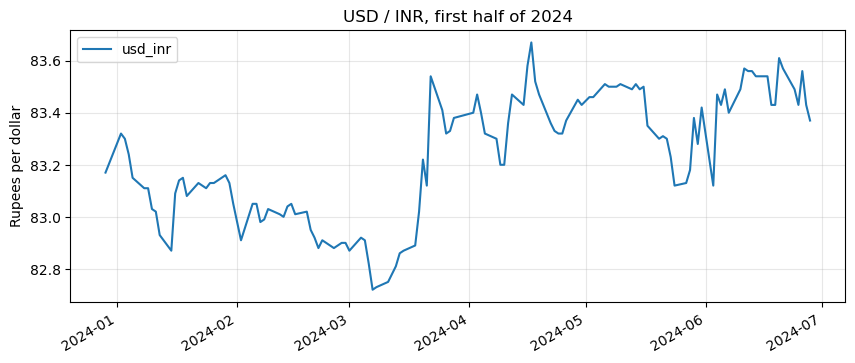

In [131]:
fx.plot(figsize=(10, 4), title="USD / INR, first half of 2024")
plt.ylabel("Rupees per dollar")
plt.grid(alpha=0.3)
plt.show()

## 4.4 Market data with yfinance

`yfinance` is a library that wraps Yahoo Finance's API, so you get a DataFrame back
directly instead of raw JSON. Handy Indian tickers:

| Ticker | What it is |
|---|---|
| `^NSEI` | NIFTY 50 index |
| `^NSEBANK` | BANK NIFTY index |
| `RELIANCE.NS` | Reliance on NSE |
| `TCS.NS` | TCS on NSE |

The `.NS` suffix means NSE. Use `.BO` for BSE.

In [133]:
pip install yfinance


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [134]:
import yfinance as yf

nifty = yf.download("^NSEI", period="6mo", interval="1d", auto_adjust=True, progress=False)

# Newer yfinance versions return two-level column names. Flatten them so the
# columns are simply Open, High, Low, Close, Volume.
if isinstance(nifty.columns, pd.MultiIndex):
    nifty.columns = nifty.columns.get_level_values(0)

print(nifty.shape)
nifty.head()

(122, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-02-02,25088.400391,25108.099609,24679.400391,24796.500000,449200
2026-02-03,25727.550781,26341.199219,25641.300781,26308.050781,637300
2026-02-04,25776.000000,25818.550781,25563.949219,25675.050781,429800
2026-02-05,25642.800781,25757.650391,25579.500000,25755.900391,343800
2026-02-06,25693.699219,25703.949219,25491.900391,25605.800781,375500


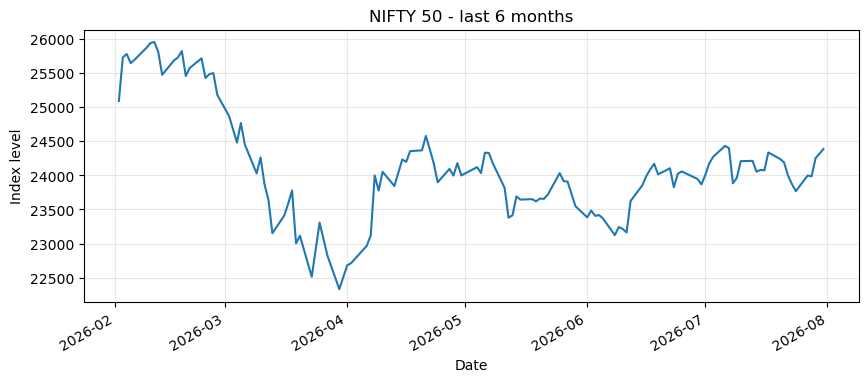

In [135]:
nifty["Close"].plot(figsize=(10, 4), title="NIFTY 50 - last 6 months")
plt.ylabel("Index level")
plt.grid(alpha=0.3)
plt.show()

---
# 5. Saving your data to Excel or Google Sheets

You will often want to hand the result to someone who lives in a spreadsheet.
Here are the ways to do that.

## 5.1 Excel — one sheet

`df.to_excel("name.xlsx", index=False)`.

This needs the `openpyxl` library installed (`pip install openpyxl`), which Pandas
uses under the bonnet to write the file. You do not need to import it yourself.

In [138]:
df.to_excel("options_data.xlsx", index=False, sheet_name="Chain")
print("Written to options_data.xlsx")

# Read it back to check
check = pd.read_excel("options_data.xlsx", sheet_name="Chain")
print(check.head(3))

Written to options_data.xlsx
   strike type    ltp      oi  volume  contract_value  oi_lakhs liquidity  \
0   24300   CE  310.5  120000   45000         23287.5      1.20    normal   
1   24400   CE  228.0  185000   62000         17100.0      1.85    normal   
2   24500   CE  152.3  310000   98000         11422.5      3.10      high   

   ltp_rounded  
0          310  
1          228  
2          152  


## 5.2 Excel — several sheets in one file

Use `pd.ExcelWriter`. The `with` block opens the file, writes everything inside,
and closes it properly when the block ends.

In [140]:
calls = df[df["type"] == "CE"]
puts = df[df["type"] == "PE"]
summary = df.groupby("type")[["ltp", "oi"]].mean().reset_index()

with pd.ExcelWriter("options_report.xlsx", engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="All Data", index=False)
    calls.to_excel(writer, sheet_name="Calls", index=False)
    puts.to_excel(writer, sheet_name="Puts", index=False)
    summary.to_excel(writer, sheet_name="Summary", index=False)

print("Written 4 sheets to options_report.xlsx")

# See what sheets a workbook contains
print("Sheets:", pd.ExcelFile("options_report.xlsx").sheet_names)

Written 4 sheets to options_report.xlsx
Sheets: ['All Data', 'Calls', 'Puts', 'Summary']


## 5.3 Reading an existing Excel file

- `sheet_name="Calls"` reads one named sheet
- `sheet_name=None` reads **all** sheets and gives you a dictionary of DataFrames
- `skiprows=3` skips junk rows at the top, which real-world files are full of

In [142]:
one = pd.read_excel("options_report.xlsx", sheet_name="Calls")
print(one)

everything = pd.read_excel("options_report.xlsx", sheet_name=None)
print("\nGot a dictionary with keys:", list(everything.keys()))
print("Rows in the Summary sheet:", len(everything["Summary"]))

   strike type    ltp      oi  volume  contract_value  oi_lakhs liquidity  \
0   24300   CE  310.5  120000   45000         23287.5      1.20    normal   
1   24400   CE  228.0  185000   62000         17100.0      1.85    normal   
2   24500   CE  152.3  310000   98000         11422.5      3.10      high   

   ltp_rounded  
0          310  
1          228  
2          152  

Got a dictionary with keys: ['All Data', 'Calls', 'Puts', 'Summary']
Rows in the Summary sheet: 2


## 5.4 Google Sheets

Three routes, easiest first.

**Route A — write an Excel file, then upload it.** Run `to_excel` as above, go to
Google Drive, drag the file in, right-click and choose *Open with Google Sheets*.
No code, no setup. For a one-off, this is genuinely the right answer.

**Route B — you are in Google Colab.** Colab already knows who you are, so
authentication is two lines. See the code cell below.

**Route C — from your own machine with `gspread`.** This needs a one-time setup:

1. Go to `console.cloud.google.com`, create a project.
2. Enable the *Google Sheets API* and the *Google Drive API*.
3. Create a **Service Account** and download its JSON key file.
4. Open your Google Sheet and **share it** with the service account's email address
   (it looks like `something@project.iam.gserviceaccount.com`), giving it Editor access.
   Miss this step and you will get a permission error — it is the usual culprit.

Then `pip install gspread gspread-dataframe` and use the code below.

In [144]:
# ============================================================
# ROUTE B - Google Colab. Remove the # marks to run in Colab.
# ============================================================

# from google.colab import auth
# import gspread
# from google.auth import default
# from gspread_dataframe import set_with_dataframe
#
# auth.authenticate_user()
# creds, _ = default()
# gc = gspread.authorize(creds)
#
# sheet = gc.create("My Options Data")          # or gc.open("Existing Sheet Name")
# worksheet = sheet.get_worksheet(0)
# set_with_dataframe(worksheet, df)             # writes the whole DataFrame
# print("Sheet URL:", sheet.url)


# ============================================================
# ROUTE C - your own machine, with a service account key file
# ============================================================

# import gspread
# from gspread_dataframe import set_with_dataframe, get_as_dataframe
#
# gc = gspread.service_account(filename="my-key.json")
#
# sheet = gc.open("My Options Data")            # must already be shared with the service account
# worksheet = sheet.sheet1
#
# # WRITE
# worksheet.clear()
# set_with_dataframe(worksheet, df)
#
# # READ back into a DataFrame
# df_from_sheets = get_as_dataframe(worksheet).dropna(how="all")
# print(df_from_sheets.head())

print("The Google Sheets code above is commented out on purpose - it needs your own credentials.")

The Google Sheets code above is commented out on purpose - it needs your own credentials.


### Quick comparison

| | CSV | Excel (.xlsx) | Google Sheets |
|---|---|---|---|
| Multiple sheets | No | Yes | Yes |
| Formatting, colours, formulas | No | Yes | Yes |
| File size | Smallest | Bigger | Lives online |
| Share with a colleague | Attach it | Attach it | Send a link |
| Setup needed | None | `openpyxl` | Google credentials |

Rule of thumb: CSV for feeding data into other code, Excel for a deliverable,
Google Sheets when several people need to look at it at once.

---
# 6. Solved Question

> **The task**
>
> 1. Download the last 6 months of daily NIFTY 50 data.
> 2. Use NumPy to work out the daily percentage return.
> 3. Add columns: the day of the week, and a label for whether the move was big
>    (more than 1% either way).
> 4. Filter out the big-move days.
> 5. Use groupby to find the average return and volatility for each day of the week.
> 6. Fetch today's USD/INR rate from an API and add the NIFTY level in dollars.
> 7. Save everything to an Excel file with three sheets.

This uses every idea from the notebook. Work through it cell by cell.

### Step 1 — get the data

In [148]:
import numpy as np
import pandas as pd
import requests
import yfinance as yf

nifty = yf.download("^NSEI", period="6mo", interval="1d", auto_adjust=True, progress=False)

if isinstance(nifty.columns, pd.MultiIndex):
    nifty.columns = nifty.columns.get_level_values(0)

nifty = nifty[["Open", "High", "Low", "Close", "Volume"]].copy()
print("Downloaded", len(nifty), "trading days")
nifty.head()

Downloaded 122 trading days


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-02-02,24796.500000,25108.099609,24679.400391,25088.400391,449200
2026-02-03,26308.050781,26341.199219,25641.300781,25727.550781,637300
2026-02-04,25675.050781,25818.550781,25563.949219,25776.000000,429800
2026-02-05,25755.900391,25757.650391,25579.500000,25642.800781,343800
2026-02-06,25605.800781,25703.949219,25491.900391,25693.699219,375500


### Step 2 — daily returns with NumPy

`.shift(1)` moves the column down one row, so each row can see yesterday's close.
The very first row has nothing before it, so its return is `NaN` — we drop it.

In [150]:
close = nifty["Close"].values                 # .values turns the column into a NumPy array

returns = np.zeros(len(close))                # start with an array of zeros
returns[0] = np.nan                           # no previous day for row 0
returns[1:] = (close[1:] - close[:-1]) / close[:-1] * 100

nifty["return_pct"] = np.round(returns, 3)
nifty = nifty.dropna(subset=["return_pct"])

print(nifty[["Close", "return_pct"]].head())

Price              Close  return_pct
Date                                
2026-02-03  25727.550781       2.548
2026-02-04  25776.000000       0.188
2026-02-05  25642.800781      -0.517
2026-02-06  25693.699219       0.198
2026-02-09  25867.300781       0.676


### Step 3 — new columns

The index is already a date, so `.index.day_name()` gives us the weekday for free.
`np.where` handles the conditional label, and `np.abs` gives the size of the move
regardless of direction.

In [152]:
nifty["weekday"] = nifty.index.day_name()
nifty["abs_move"] = np.abs(nifty["return_pct"])
nifty["big_move"] = np.where(nifty["abs_move"] > 1.0, "Yes", "No")
nifty["direction"] = np.where(nifty["return_pct"] > 0, "Up", "Down")

nifty[["Close", "return_pct", "weekday", "big_move", "direction"]].head(8)

Price,Close,return_pct,weekday,big_move,direction
Date,,,,,
2026-02-03,25727.550781,2.548,Tuesday,Yes,Up
2026-02-04,25776.000000,0.188,Wednesday,No,Up
2026-02-05,25642.800781,-0.517,Thursday,No,Down
2026-02-06,25693.699219,0.198,Friday,No,Up
2026-02-09,25867.300781,0.676,Monday,No,Up
2026-02-10,25935.150391,0.262,Tuesday,No,Up
2026-02-11,25953.849609,0.072,Wednesday,No,Up
2026-02-12,25807.199219,-0.565,Thursday,No,Down


### Step 4 — filter

In [154]:
big_days = nifty[nifty["big_move"] == "Yes"]

print(f"{len(big_days)} big-move days out of {len(nifty)} "
      f"({len(big_days) / len(nifty) * 100:.1f}% of the time)")

print("\nThe five largest moves:")
print(big_days.sort_values("abs_move", ascending=False)
              [["Close", "return_pct", "weekday", "direction"]].head())

38 big-move days out of 121 (31.4% of the time)

The five largest moves:
Price              Close  return_pct    weekday direction
Date                                                     
2026-04-08  23997.349609       3.778  Wednesday        Up
2026-03-19  23002.150391      -3.262   Thursday      Down
2026-03-23  22512.650391      -2.604     Monday      Down
2026-02-03  25727.550781       2.548    Tuesday        Up
2026-03-30  22331.400391      -2.139     Monday      Down


### Step 5 — groupby

Standard deviation of returns is a common stand-in for volatility. Notebook 2 goes
into what it actually measures.

In [156]:
by_day = nifty.groupby("weekday")["return_pct"].agg(["count", "mean", "std", "min", "max"])
by_day = by_day.round(3)

# Put the days back in calendar order instead of alphabetical
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
by_day = by_day.reindex([d for d in order if d in by_day.index])

print(by_day)

print("\nUp days vs down days:")
print(nifty["direction"].value_counts())

           count   mean    std    min    max
weekday                                     
Monday        25 -0.107  1.110 -2.604  1.317
Tuesday       23  0.115  0.954 -1.832  2.548
Wednesday     26  0.321  1.201 -2.118  3.778
Thursday      24 -0.241  0.905 -3.262  1.183
Friday        23 -0.205  1.085 -2.089  1.992

Up days vs down days:
direction
Up      65
Down    56
Name: count, dtype: int64


### Step 6 — the API bit

In [158]:
fx_data = requests.get("https://api.frankfurter.app/latest?from=USD&to=INR", timeout=10).json()
usd_inr = fx_data["rates"]["INR"]

print(f"1 USD = {usd_inr} INR   (as of {fx_data['date']})")

nifty["close_usd"] = (nifty["Close"] / usd_inr).round(2)
print(nifty[["Close", "close_usd"]].tail(3))

1 USD = 95.39 INR   (as of 2026-07-31)
Price              Close  close_usd
Date                               
2026-07-29  24250.199219     254.22
2026-07-30  24317.150391     254.92
2026-07-31  24383.599609     255.62


### Step 7 — save it

In [160]:
with pd.ExcelWriter("nifty_analysis.xlsx", engine="openpyxl") as writer:
    nifty.to_excel(writer, sheet_name="Daily Data")
    big_days.to_excel(writer, sheet_name="Big Moves")
    by_day.to_excel(writer, sheet_name="By Weekday")

print("Saved nifty_analysis.xlsx")
print("Sheets:", pd.ExcelFile("nifty_analysis.xlsx").sheet_names)

Saved nifty_analysis.xlsx
Sheets: ['Daily Data', 'Big Moves', 'By Weekday']


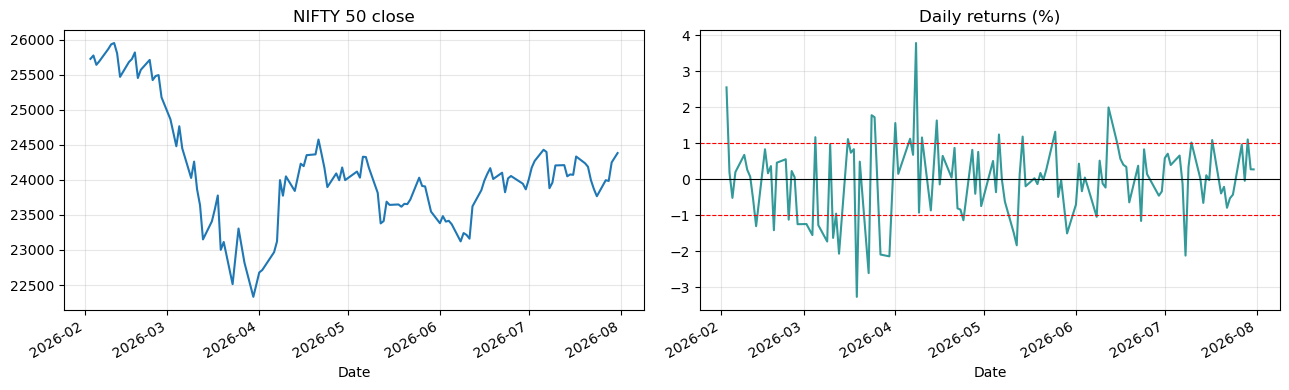

In [161]:
# A chart to finish
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

nifty["Close"].plot(ax=axes[0], title="NIFTY 50 close")
axes[0].grid(alpha=0.3)

nifty["return_pct"].plot(ax=axes[1], title="Daily returns (%)", color="teal", alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axhline(1, color="red", linestyle="--", linewidth=0.8)
axes[1].axhline(-1, color="red", linestyle="--", linewidth=0.8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
# 7. Practice Question

Do this one yourself. It uses the same tools, applied to a different problem.

> **The task**
>
> Compare **Reliance** (`RELIANCE.NS`) and **TCS** (`TCS.NS`) over the last year.
>
> 1. Download 1 year of daily data for both.
> 2. For each stock, calculate the daily percentage return using NumPy.
> 3. Build a single DataFrame with columns: `date`, `reliance_close`, `tcs_close`,
>    `reliance_return`, `tcs_return`.
> 4. Add a column `better_performer` holding either `"RELIANCE"` or `"TCS"`,
>    whichever had the higher return that day.
> 5. Add a `month` column and use groupby to get the average monthly return of each stock.
> 6. Write a function `summarise(returns)` that takes an array of returns and returns
>    a dictionary with the mean, standard deviation, best day, worst day, and the
>    percentage of days that were positive. Call it on both stocks.
> 7. Filter to days where **both** stocks fell more than 1%. How many were there?
> 8. Fetch the USD/INR rate from the Frankfurter API and add both closing prices in dollars.
> 9. Save to `stock_comparison.xlsx` with three sheets: `Daily`, `Monthly`, `Summary`.
> 10. Plot both stocks on one chart. (Hint: normalise both to start at 100 so they are
>     comparable — divide the column by its first value and multiply by 100.)

**Hints**

- `yf.download(["RELIANCE.NS", "TCS.NS"], period="1y")` fetches both at once, but the
  columns come back two-level. It is simpler to download them separately and combine.
- `pd.concat([a, b], axis=1)` joins two DataFrames side by side.
- `df.index.to_period("M")` turns dates into months for grouping.
- For step 6, return a dictionary: `{"mean": ..., "std": ...}`.
- For step 7, remember each condition needs its own brackets, joined by `&`.

**How to know you got it right**

- Your daily DataFrame should have roughly 240–250 rows (Indian trading days in a year).
- The percentage of positive days should land somewhere near 50%, usually a little above.
- The Excel file should open with exactly three tabs.

In [163]:
# Your answer here.
# Write it in small steps and print as you go - do not try to write it all at once.

import numpy as np
import pandas as pd
import yfinance as yf
import requests

# Step 1: download the data


# Step 2: returns


# Step 3: combine into one DataFrame


# ... keep going

---
### That is Notebook 1.

You now have the tools to load data, reshape it, and get it out again.
Notebook 2 takes real NIFTY option chain data and asks the next question:
**what does this data actually tell us?**